# FINAL Step 2.1 — Tissue Classification: Paper-Style Replication

A **self-sufficient** replication / re-evaluation of the Razali et al. (2023) background-tissue task —
**fatty vs fibroglandular** — on INbreast. It runs **start to finish on its own**: it loads the
fatty/fibroglandular patches, computes its own features, and trains its own models. It does **not** depend
on running Step 2.1 / 2.2 / 2.3 first, and reads **no** old WS / CNN / fusion feature files.

This is the tissue counterpart of *FINAL Step 2.2 — Mass Classification Paper-Style Replication*, using the
**identical evaluation protocol**.

**Inputs (genuine dataset / preprocessing artefacts only):**
- `../data/outputs/background_patches/patches_index.csv` — fatty/fibroglandular patch manifest (Step 1.3).
- `../data/outputs/background_patches/{fatty,fibroglandular}/*.npy` — the $224\times224$ patches.

**Outputs (fresh, isolated folder — nothing existing is overwritten):**
- `../data/outputs/final_tissue_replication/`

**Scope — paper-style methods only:** majority baseline, averaged WS-only, ResNet18 CNN-only, CNN+WS
concatenation fusion. Extension methods are out of scope (the mass extensions are in *FINAL Step 2.4*).

## Method summary (Razali Table 6 replication)

**Patches.** Fatty/fibroglandular $224\times224$ background patches sampled in Step 1.3 from the
preprocessed images (percentile-clip → breast-mask → pectoral removal → CLAHE), loaded directly from
`patches_index.csv` (a genuine preprocessing artefact). Labels: **fatty → 0, fibroglandular → 1**.

**WS-only (Model 2).** Kymatio `Scattering2D` ($J=6$, $L=5$, `max_order=2`) on each patch; each coefficient
map is **spatially averaged to one scalar** → **406-d** vector (paper reports 391; minor library
difference).

**CNN-only (Model 1).** ImageNet ResNet18, final FC → $512\to2$; grayscale replicated to 3 channels,
ImageNet mean/std normalisation, no augmentation; **Adam, lr $10^{-3}$, $L_2=10^{-4}$, 60 epochs, batch
80** (paper Table 4). Then **512-d average-pool features** are classified.

**CNN+WS fusion (Model 5).** Concatenate CNN 512-d + WS 406-d → **918-d**, then classify.

**Classifier (all).** Subspace $k$-NN ensemble — **80 learners**, **1-NN** on random **190-d** subspaces,
soft-voted; `StandardScaler` fit on the training fold only.

**Paper benchmark (Razali Table 6, fatty vs fibroglandular):**

| Metric | Model 1 CNN-only | Model 2 WS-only | Model 5 CNN+WS |
|---|---|---|---|
| 10-fold CV acc | 99.0% | 91.1% | 99.3% |
| Test acc | 77.4% | 91.4% | 93.5% |
| AU-ROC | 0.90 | 0.94 | 0.96 |
| F1 | 0.808 | 0.910 | 0.934 |

(Models 3/4/6 use GLCM and are out of scope on supervisor advice.)

## Evaluation protocol (locked — identical to the mass notebook)

- **Fair evaluation (headline):** repeated **stratified, image-level** 80/20 holdout over **5 seeds**
  `[1, 7, 34, 42, 99]`, grouped by `file_id`, scalers fit on the training fold only, **AUROC-led**,
  reported as **mean ± std**. Because each mammogram contributes *both* fatty and fibroglandular patches,
  the image-level split is **stratified by ACR breast-density category** (the image-level attribute), not
  by patch label.
- **Leakage-free CNN:** the ResNet is **retrained inside each split** on that split's training images only.
- **Paper comparison (secondary):** single-seed (seed 34) **10-fold group-aware CV accuracy** — Razali's
  exact metric. For learned-feature methods (CNN, fusion) this CV is **optimistic** (the extractor saw the
  inner-fold images).

> **Why image-level splitting.** Each mammogram yields multiple patches; a patch-level split would put
> patches from the same image in both train and test, leaking image-specific appearance and inflating
> scores. We split on unique `file_id`. (An early patch-level CNN run produced an implausible 100% on every
> metric — the diagnosis that established this rule for both tasks.)

## Method fidelity — what the paper specifies, what it leaves open, and our choices

This notebook follows Razali et al. (2023) as closely as the paper's description allows: where the paper is explicit we match it; where it is silent we state the assumption we made and why.

- **Normalisation.** *Paper:* DICOM → PNG (an implicit min-max windowing) → rescale to [0, 1]. *Left open:* how outlier pixels (calibration markers, sensor hot-spots) are handled. *Ours:* 1st/99th-percentile clip → [0, 1]; a raw min-max ablation compressed real tissue into a narrow band and lowered CV by ~3 pp, so the percentile clip is the robust choice.
- **Patch extraction / labelling.** *Paper:* Otsu threshold on the breast region to split fatty vs fibroglandular. *Left open:* no density-aware filtering is described. *Ours:* ACR-guided sampling (ACR 1 → fatty only, ACR 4 → fibroglandular only, ACR 2–3 → both) to avoid forcing a binary split on a near-uniform breast — 434 patches vs the paper's 397.
- **Wavelet scattering.** *Paper:* MATLAB `waveletScattering`, J = 6, L = 6, order 2 → 391-d (MATLAB defaults, no ablation). *Ours:* Kymatio, J = 6, L = 5, order 2 → 406-d. The 391-vs-406 gap is purely a library convention (MATLAB reserves one scale for the low-pass and uses 6 orientations).
- **CNN branch.** *Paper:* ResNet18 (shallow, chosen for the small dataset), Adam lr 0.001 / L2 1e-4 / β₁ 0.9 / 60 epochs / batch 80, fine-tuned, used as a feature extractor (Table 4). *Left open:* which layer the features come from, and freeze vs full fine-tune. *Ours:* identical hyperparameters (PyTorch); 512-d average-pool features; all layers fine-tuned (MATLAB `trainNetwork` default).
- **Classifier.** *Paper:* Subspace k-NN ensemble, 80 learners, subspace dimension 190 (Table 5 optimal). *Left open:* the base-learner neighbour count and whether features are standardised. *Ours:* 1-NN base learners (MATLAB default) and a `StandardScaler` fit on the training fold only — k-NN is distance-based, so scaling matters and the paper does not mention it.
- **CNN + WS fusion.** *Paper:* simple concatenation of the two feature vectors → the same Subspace k-NN, with no feature selection or dimensionality reduction (Model 5; Model 6 adds GLCM but gains nothing). *Left open:* whether/how the two halves are scaled, and concatenation order. *Ours:* standardise the 918-d (512 + 406) fused vector on training statistics so the differently-scaled halves contribute comparably; order is irrelevant for a random-subspace classifier (see the fusion-design note below).
- **Train/test split and evaluation.** *Paper:* a "randomized 8:2" split with 10-fold cross-validation. *Left open:* whether the split is patch-level or image-level. *Ours:* image-level (grouped by `file_id`) — an early patch-level run produced an implausible 100% on every metric (leakage), which established this rule. Beyond the paper, we also report a repeated five-seed image-level holdout, AUROC-led, for an honest estimate on these small test sets.

In [1]:
import os, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch, torch.nn as nn, torchvision
from torch.utils.data import Dataset, DataLoader
from kymatio.scattering2d.frontend.numpy_frontend import ScatteringNumPy2D as Scattering2D
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, RocCurveDisplay)

ROOT = Path("/home/nabeel/project34/Project34")
PATCH_INDEX = Path("../data/outputs/background_patches/patches_index.csv")
OUT = Path("../data/outputs/final_tissue_replication"); OUT.mkdir(parents=True, exist_ok=True)
import sys as _sys
if str(ROOT) not in _sys.path: _sys.path.insert(0, str(ROOT))   # make the shared project34 package importable
from project34.protocol import SubspaceKNN, SEEDS               # shared protocol; SEEDS == [1, 7, 34, 42, 99]
J, L = 6, 5; PATCH_SHAPE = (224, 224)
device = "cpu"; torch.set_num_threads(os.cpu_count() or 4)
CLASSES = ["fatty", "fibroglandular"]

# Razali Table 6 (tissue) benchmark
PAPER = {
    "WS-only (averaged)":       dict(cv=0.911, test=0.914, auroc=0.94, f1=0.910),
    "CNN-only (ResNet18->kNN)": dict(cv=0.990, test=0.774, auroc=0.90, f1=0.808),
    "CNN+WS fusion (concat)":   dict(cv=0.993, test=0.935, auroc=0.96, f1=0.934),
}
def resolve(p):
    s = str(p).replace("\\", "/"); i = s.find("data/outputs/")
    return (ROOT / s[i:]) if i >= 0 else Path(s)
print("input present:", PATCH_INDEX.exists())

input present: True


## Step A — Load fatty / fibroglandular patches

In [2]:
df = pd.read_csv(PATCH_INDEX)
df = df[df["label"].isin(CLASSES)].copy()
df["patch_npy"] = df["patch_npy"].apply(resolve)
df = df[df["patch_npy"].apply(lambda p: p.exists())].reset_index(drop=True)
df["class_id"] = df["label"].map({"fatty": 0, "fibroglandular": 1})
y_all = df["class_id"].to_numpy(np.int64); g_all = df["file_id"].to_numpy(); paths = df["patch_npy"].tolist()
acr_by_img = df.groupby("file_id")["acr"].first()
df.to_csv(OUT / "tissue_manifest.csv", index=False)
print(f"{len(df)} patches ({df['label'].value_counts().to_dict()}) from {df['file_id'].nunique()} images")
print("ACR over images:", acr_by_img.value_counts().sort_index().to_dict())

434 patches ({'fatty': 251, 'fibroglandular': 183}) from 100 images
ACR over images: {1: 36, 2: 35, 3: 21, 4: 8}


## Step B — WS features (Kymatio scattering, spatially averaged → 406-d)
Cached to `final_tissue_replication/ws_tissue_features.npy`.

In [3]:
def load_patch01(p):
    a = np.load(p).astype(np.float32); a = np.nan_to_num(a, nan=0., posinf=1., neginf=0.)
    return np.clip(a, 0., 1.)

_wsf = OUT / "ws_tissue_features.npy"
scat = Scattering2D(J=J, shape=PATCH_SHAPE, L=L, max_order=2)
if _wsf.exists() and np.load(_wsf).shape[0] == len(df):
    WS = np.load(_wsf); print("Loaded cached WS features", WS.shape)
else:
    t0 = time.time()
    WS = np.stack([scat(load_patch01(p)).mean(axis=(1, 2)).astype(np.float32) for p in paths])
    np.save(_wsf, WS); print(f"Computed WS features {WS.shape} in {time.time()-t0:.0f}s")

Loaded cached WS features (434, 406)


### WS coefficient sanity check

Before classification, a quick check that the scattering transform produced sensible features: the number of
coefficients per patch and its decomposition by scattering order (order 0 + order 1 + order 2 = 1 + J*L + C(J,2)*L^2 = 406 for J=6, L=5), and — for one sample patch — the patch, its first 80 scattering
coefficients, and the distribution of all 406 coefficient values.

WS feature length per patch : 406   (feature matrix (434, 406))
  order 0 (low-pass)        : 1
  order 1  (J*L)            : 30
  order 2  (C(J,2)*L^2)     : 375
  total                     : 406

Sample patch: label=fatty, shape=(224, 224)


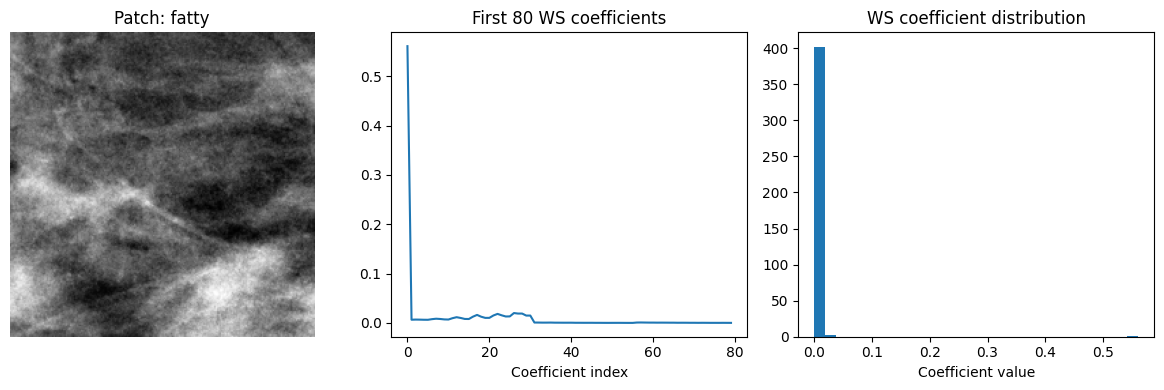

In [4]:
# WS coefficient sanity check: count, per-order breakdown, and a one-patch visualisation
_n0 = 1
_n1 = J * L
_n2 = (J * (J - 1) // 2) * (L ** 2)
print(f"WS feature length per patch : {WS.shape[1]}   (feature matrix {WS.shape})")
print(f"  order 0 (low-pass)        : {_n0}")
print(f"  order 1  (J*L)            : {_n1}")
print(f"  order 2  (C(J,2)*L^2)     : {_n2}")
print(f"  total                     : {_n0 + _n1 + _n2}")

_si = 0
_patch = load_patch01(paths[_si]); _feat = WS[_si]
print(f"\nSample patch: label={df.iloc[_si]['label']}, shape={_patch.shape}")
_fig, _ax = plt.subplots(1, 3, figsize=(12, 4))
_ax[0].imshow(_patch, cmap="gray"); _ax[0].set_title(f"Patch: {df.iloc[_si]['label']}"); _ax[0].axis("off")
_ax[1].plot(_feat[:80]); _ax[1].set_title("First 80 WS coefficients"); _ax[1].set_xlabel("Coefficient index")
_ax[2].hist(_feat, bins=30); _ax[2].set_title("WS coefficient distribution"); _ax[2].set_xlabel("Coefficient value")
plt.tight_layout(); plt.savefig(OUT / "ws_coefficient_sanity_check.png", dpi=150, bbox_inches="tight"); plt.show()

## Step C — Subspace k-NN ensemble + CNN definitions

In [5]:
# SubspaceKNN is imported from project34.protocol (identical paper-style Subspace k-NN ensemble).

IMN=[0.485,0.456,0.406]; IST=[0.229,0.224,0.225]
class DS(Dataset):
    '''Grayscale patch -> 3-channel ImageNet-normalised tensor (matches the paper's CNN input).'''
    def __init__(self, idx): self.idx=idx; self.norm=torchvision.transforms.Normalize(IMN, IST)
    def __len__(self): return len(self.idx)
    def __getitem__(self, k):
        i=self.idx[k]; a=load_patch01(paths[i]); t=torch.from_numpy(a)[None].repeat(3,1,1); return self.norm(t), int(y_all[i])

def train_cnn(tr_idx, seed):
    '''Fine-tune ResNet18 (ImageNet) on the split's training patches only; return (model, per-epoch history).'''
    torch.manual_seed(seed); np.random.seed(seed)
    m=torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc=nn.Linear(512,2); m.to(device)
    opt=torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4); crit=nn.CrossEntropyLoss()
    dl=DataLoader(DS(list(tr_idx)), batch_size=80, shuffle=True); hist=[]
    for ep in range(60):
        m.train(); run_loss=0.0; correct=0; total=0
        for xb,yb in dl:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad()
            out=m(xb); loss=crit(out,yb); loss.backward(); opt.step()
            run_loss+=loss.item()*xb.size(0); correct+=(out.argmax(1)==yb).sum().item(); total+=xb.size(0)
        hist.append(dict(epoch=ep+1, loss=run_loss/total, acc=correct/total))
    return m, hist

def extract_512(m):
    '''512-d average-pool features for ALL patches from the fine-tuned model.'''
    m.fc=nn.Identity(); m.eval()
    dl=DataLoader(DS(list(range(len(paths)))), batch_size=80, shuffle=False); fe=[]
    with torch.no_grad():
        for xb,_ in dl: fe.append(m(xb.to(device)).cpu().numpy())
    return np.vstack(fe).astype(np.float32)

### Note on the CNN+WS fusion design (Model 5)

Following the paper, fusion is the **simple concatenation** of the per-patch CNN and WS feature vectors —
512 (ResNet18 average-pool) + 406 (averaged scattering) = **918-d** — classified by the *same* Subspace k-NN
ensemble as the single-feature models. Two design points the paper leaves implicit but that matter here:

- **Standardisation of mixed-magnitude features.** The CNN average-pool activations and the WS coefficients
  live on very different numerical scales, so concatenating them raw would let the larger-magnitude half
  dominate the distance-based k-NN. We therefore fit a `StandardScaler` (zero mean, unit variance per feature)
  on the **training fold only** and apply it to the 918-d fused vector, so both halves contribute comparably.
- **No explicit feature selection or dimensionality reduction.** None is applied between concatenation and the
  classifier; the random-subspace ensemble (each learner sees a random 190-d subset of the 918) *is* the
  implicit feature selection. The concatenation order ([CNN | WS] vs [WS | CNN]) is therefore irrelevant — the
  random subspace sampling makes no use of column position.

In [6]:
# CNN+WS fusion dimensionality (sanity check) — 512 CNN avg-pool + 406 WS, no GLCM
_cnn_dim, _ws_dim = 512, WS.shape[1]
print(f"CNN+WS fusion: {_cnn_dim} (CNN avg-pool) + {_ws_dim} (WS) = {_cnn_dim + _ws_dim}-d per patch  (no GLCM)")
assert _cnn_dim + _ws_dim == 918

CNN+WS fusion: 512 (CNN avg-pool) + 406 (WS) = 918-d per patch  (no GLCM)


## Step D — Run the locked protocol (repeated 5-seed held-out + seed-34 CV)

For each seed: ACR-stratified image-level split; evaluate majority / WS-only / CNN-only / fusion on the
held-out test set (CNN retrained per seed). For seed 34: also compute the single-seed 10-fold CV (paper
comparison) and save the CNN training curve + fusion test predictions for the diagnostic plots. Heavy
results are cached to `final_tissue_replication/`.

In [7]:
def metrics(y, yp, pr):
    return dict(test_acc=accuracy_score(y, yp),
                auroc=roc_auc_score(y, pr) if len(np.unique(y)) > 1 else np.nan,
                precision=precision_score(y, yp, zero_division=0),
                recall=recall_score(y, yp, zero_division=0), f1=f1_score(y, yp, zero_division=0))

def run_knn(Xtr, ytr, Xte, yte, seed):
    sc=StandardScaler(); Xtr=sc.fit_transform(Xtr); Xte=sc.transform(Xte)
    clf=SubspaceKNN(80, min(190, Xtr.shape[1]), 1, seed).fit(Xtr, ytr)
    yp=clf.predict(Xte); pr=clf.predict_proba(Xte)[:, 1]
    return metrics(yte, yp, pr), yp, pr

def image_level_split(seed):
    meta = acr_by_img.reset_index()
    _, te_f = train_test_split(meta["file_id"], test_size=0.2, stratify=meta["acr"], random_state=seed, shuffle=True)
    is_test = df["file_id"].isin(set(te_f)).to_numpy()
    return np.where(~is_test)[0], np.where(is_test)[0]

_perseed = OUT / "perseed_tissue.csv"; _cv = OUT / "cv_seed34_tissue.csv"
if _perseed.exists() and _cv.exists():
    perseed = pd.read_csv(_perseed); cvdf = pd.read_csv(_cv); print("Loaded cached per-seed + CV results.")
else:
    rows, cv_rows = [], []
    for seed in SEEDS:
        tr, te = image_level_split(seed); ytr, yte = y_all[tr], y_all[te]
        maj = int(pd.Series(ytr).value_counts().idxmax())
        rows.append(dict(method="Majority baseline", seed=seed, n_test=len(te),
                         **metrics(yte, np.full(len(te), maj), np.full(len(te), float(maj)))))
        mws, _, _ = run_knn(WS[tr], ytr, WS[te], yte, seed)
        rows.append(dict(method="WS-only (averaged)", seed=seed, n_test=len(te), **mws))
        t1=time.time(); m, hist = train_cnn(tr, seed); F=extract_512(m)
        mcnn, _, _ = run_knn(F[tr], ytr, F[te], yte, seed)
        rows.append(dict(method="CNN-only (ResNet18->kNN)", seed=seed, n_test=len(te), **mcnn))
        FU = np.hstack([F, WS])
        mfu, yp_fu, pr_fu = run_knn(FU[tr], ytr, FU[te], yte, seed)
        rows.append(dict(method="CNN+WS fusion (concat)", seed=seed, n_test=len(te), **mfu))
        if seed == 34:
            pd.DataFrame(hist).to_csv(OUT / "cnn_history_seed34.csv", index=False)
            np.savez(OUT / "diag_seed34_fusion.npz", y_true=yte, y_pred=yp_fu, y_proba=pr_fu)
            cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=34); gtr = g_all[tr]
            def cv_acc(X):
                pipe=Pipeline([("sc", StandardScaler()), ("clf", SubspaceKNN(80, min(190, X.shape[1]), 1, 34))])
                s=cross_val_score(pipe, X, ytr, cv=cv, groups=gtr, scoring="accuracy", n_jobs=1); return s.mean(), s.std()
            dacc=cross_val_score(Pipeline([("clf", DummyClassifier(strategy="most_frequent"))]), WS[tr], ytr, cv=cv, groups=gtr, scoring="accuracy", n_jobs=1)
            cv_rows.append(dict(method="Majority baseline", cv_acc=dacc.mean(), cv_acc_sd=dacc.std(), biased=False))
            for nm, X, b in [("WS-only (averaged)", WS[tr], False), ("CNN-only (ResNet18->kNN)", F[tr], True), ("CNN+WS fusion (concat)", FU[tr], True)]:
                a, sd = cv_acc(X); cv_rows.append(dict(method=nm, cv_acc=a, cv_acc_sd=sd, biased=b))
        print(f"seed {seed}: done ({time.time()-t1:.0f}s)", flush=True)
    perseed = pd.DataFrame(rows); perseed.to_csv(_perseed, index=False)
    cvdf = pd.DataFrame(cv_rows); cvdf.to_csv(_cv, index=False)
    print("Saved per-seed + CV results to", OUT)

Loaded cached per-seed + CV results.


## Results — master table + paper comparison
`AUROC`/`Test acc` are the fair repeated 5-seed mean ± std (headline); `CV (seed 34)` is the
paper-comparison single-seed 10-fold CV (`(opt.)` = optimistic for learned-feature methods).

In [8]:
METHODS = ["Majority baseline", "WS-only (averaged)", "CNN-only (ResNet18->kNN)", "CNN+WS fusion (concat)"]
def agg(m):
    d = perseed[perseed["method"] == m]
    return {k: d[k].mean() for k in ["auroc","test_acc","f1"]} | {k+"_sd": d[k].std() for k in ["auroc","test_acc"]}
cvmap = {r["method"]: (r["cv_acc"], r["cv_acc_sd"], bool(r["biased"])) for _, r in cvdf.iterrows()}
def cvfmt(m):
    v = cvmap.get(m); return "---" if v is None else f"{v[0]:.3f} ± {v[1]:.3f}" + ("  (opt.)" if v[2] else "")
disp_name = {"Majority baseline":"Majority baseline","WS-only (averaged)":"WS-only (averaged)",
             "CNN-only (ResNet18->kNN)":"CNN-only (ResNet18→kNN)","CNN+WS fusion (concat)":"CNN+WS fusion (concat)"}
rows = []
for m in METHODS:
    a = agg(m); role = "Baseline" if m == "Majority baseline" else "Replication"
    rows.append({"Method": disp_name[m], "Role": role, "AUROC": f"{a['auroc']:.3f} ± {a['auroc_sd']:.3f}",
                 "Test acc": f"{a['test_acc']:.3f} ± {a['test_acc_sd']:.3f}", "CV (seed 34)": cvfmt(m),
                 "F1": round(a["f1"], 3), "AUROC_num": a["auroc"], "acc_num": a["test_acc"],
                 "auroc_sd": a["auroc_sd"], "acc_sd": a["test_acc_sd"]})
for m in METHODS:
    if m in PAPER:
        p = PAPER[m]
        rows.append({"Method": f"Razali {m.split(' (')[0]} (paper)", "Role": "Paper (single split)",
                     "AUROC": f"{p['auroc']:.2f}", "Test acc": f"{p['test']:.3f}", "CV (seed 34)": f"{p['cv']:.3f}",
                     "F1": p["f1"], "AUROC_num": p["auroc"], "acc_num": p["test"], "auroc_sd": 0, "acc_sd": 0})
master = pd.DataFrame(rows); master.to_csv(OUT / "master_table_tissue.csv", index=False)
display(master[["Method","Role","AUROC","Test acc","CV (seed 34)","F1"]])

,Method,Role,AUROC,Test acc,CV (seed 34),F1
0,Majority baseline,Baseline,0.500 ± 0.000,0.570 ± 0.010,0.578 ± 0.024,0.000
1,WS-only (averaged),Replication,0.895 ± 0.070,0.839 ± 0.071,0.812 ± 0.073,0.807
2,CNN-only (ResNet18→kNN),Replication,0.979 ± 0.010,0.979 ± 0.010,1.000 ± 0.000 (opt.),0.976
3,CNN+WS fusion (concat),Replication,0.988 ± 0.007,0.964 ± 0.030,1.000 ± 0.000 (opt.),0.957
4,Razali WS-only (paper),Paper (single split),0.94,0.914,0.911,0.910
5,Razali CNN-only (paper),Paper (single split),0.90,0.774,0.990,0.808
6,Razali CNN+WS fusion (paper),Paper (single split),0.96,0.935,0.993,0.934


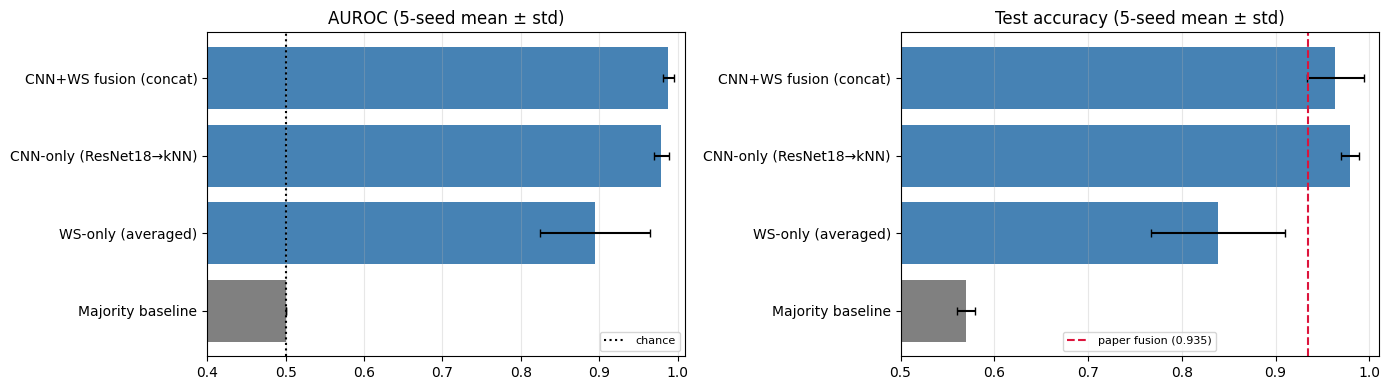

Saved /home/nabeel/project34/Project34/data/outputs/final_tissue_replication/master_table_tissue.png


In [9]:
fair = master[master["Role"] != "Paper (single split)"].copy().sort_values("AUROC_num")
colors = {"Baseline":"grey","Replication":"steelblue"}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.0))
ax[0].barh(fair["Method"], fair["AUROC_num"], xerr=fair["auroc_sd"], capsize=3, color=fair["Role"].map(colors))
ax[0].axvline(0.5, ls=":", color="black", label="chance"); ax[0].set_xlim(0.4,1.01); ax[0].set_title("AUROC (5-seed mean ± std)"); ax[0].legend(fontsize=8)
ax[1].barh(fair["Method"], fair["acc_num"], xerr=fair["acc_sd"], capsize=3, color=fair["Role"].map(colors))
ax[1].axvline(0.935, ls="--", color="crimson", label="paper fusion (0.935)")
ax[1].set_xlim(0.5,1.01); ax[1].set_title("Test accuracy (5-seed mean ± std)"); ax[1].legend(fontsize=8)
for a in ax: a.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "master_table_tissue.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved", (OUT/"master_table_tissue.png").resolve())

### Paper-CV reproduction (replication methods)

In [10]:
cmp = []
for m in ["WS-only (averaged)", "CNN-only (ResNet18->kNN)", "CNN+WS fusion (concat)"]:
    a = agg(m)
    cmp.append({"Method": m.split(" (")[0], "Our CV (seed 34)": cvfmt(m), "Paper CV": f"{PAPER[m]['cv']:.3f}",
                "Our held-out AUROC": f"{a['auroc']:.3f} ± {a['auroc_sd']:.3f}", "Paper test": f"{PAPER[m]['test']:.3f}",
                "CV honest?": "no (leakage)" if cvmap[m][2] else "yes"})
display(pd.DataFrame(cmp))

,Method,Our CV (seed 34),Paper CV,Our held-out AUROC,Paper test,CV honest?
0,WS-only,0.812 ± 0.073,0.911,0.895 ± 0.070,0.914,yes
1,CNN-only,1.000 ± 0.000 (opt.),0.990,0.979 ± 0.010,0.774,no (leakage)
2,CNN+WS fusion,1.000 ± 0.000 (opt.),0.993,0.988 ± 0.007,0.935,no (leakage)


## Diagnostics (illustrative, seed 34)

CNN training curve (overfitting signature), and the held-out confusion matrix + ROC for the CNN+WS fusion.

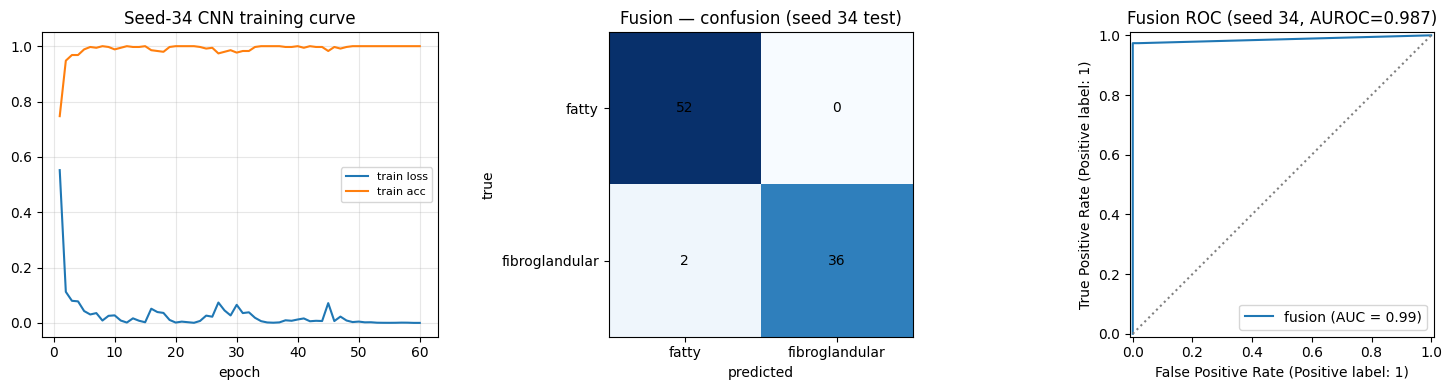

Saved /home/nabeel/project34/Project34/data/outputs/final_tissue_replication/diagnostics_seed34.png


In [11]:
hist = pd.read_csv(OUT / "cnn_history_seed34.csv")
d = np.load(OUT / "diag_seed34_fusion.npz")
yt, yp, pr = d["y_true"], d["y_pred"], d["y_proba"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(hist["epoch"], hist["loss"], label="train loss"); ax[0].plot(hist["epoch"], hist["acc"], label="train acc")
ax[0].set_xlabel("epoch"); ax[0].set_title("Seed-34 CNN training curve"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
cm = confusion_matrix(yt, yp, labels=[0, 1])
ax[1].imshow(cm, cmap="Blues"); ax[1].set_title("Fusion — confusion (seed 34 test)")
ax[1].set_xticks([0,1]); ax[1].set_xticklabels(CLASSES); ax[1].set_yticks([0,1]); ax[1].set_yticklabels(CLASSES)
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true")
for i in range(2):
    for j in range(2): ax[1].text(j, i, cm[i, j], ha="center", va="center")
RocCurveDisplay.from_predictions(yt, pr, ax=ax[2], name="fusion"); ax[2].set_title(f"Fusion ROC (seed 34, AUROC={roc_auc_score(yt,pr):.3f})"); ax[2].plot([0,1],[0,1],ls=":",color="grey")
plt.tight_layout(); plt.savefig(OUT / "diagnostics_seed34.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved", (OUT/"diagnostics_seed34.png").resolve())

### Per-class breakdown and confusion matrices (seed 34)

The per-class classification report (precision / recall / F1 for fatty vs fibroglandular) and confusion
matrices for the CNN-only and CNN+WS fusion classifiers on the seed-34 held-out split — the single-seed
detail behind the master table above. (The CNN-only predictions are cached after the first run.)

Loaded cached seed-34 CNN-only predictions.

=== CNN-only (ResNet18->kNN) - seed-34 held-out ===
                precision    recall  f1-score   support

         fatty       0.98      1.00      0.99        52
fibroglandular       1.00      0.97      0.99        38

      accuracy                           0.99        90
     macro avg       0.99      0.99      0.99        90
  weighted avg       0.99      0.99      0.99        90

=== CNN+WS fusion - seed-34 held-out ===
                precision    recall  f1-score   support

         fatty       0.96      1.00      0.98        52
fibroglandular       1.00      0.95      0.97        38

      accuracy                           0.98        90
     macro avg       0.98      0.97      0.98        90
  weighted avg       0.98      0.98      0.98        90



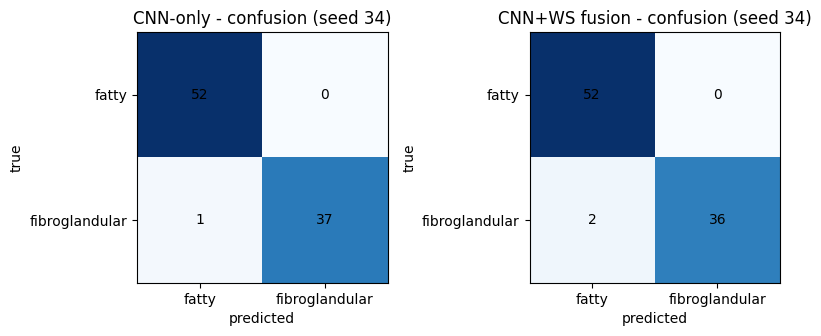

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
_pc = OUT / "diag_seed34_cnn.npz"
if _pc.exists():
    _z = np.load(_pc); _yt = _z["y_true"]; _cnn_yp = _z["cnn_pred"]
    print("Loaded cached seed-34 CNN-only predictions.")
else:
    _tr, _te = image_level_split(34); _ytr, _yt = y_all[_tr], y_all[_te]
    _m, _ = train_cnn(_tr, 34); _F = extract_512(_m)
    _mc, _cnn_yp, _ = run_knn(_F[_tr], _ytr, _F[_te], _yt, 34)
    np.savez(_pc, y_true=_yt, cnn_pred=_cnn_yp)
    print("Trained seed-34 CNN and cached CNN-only predictions.")
# fusion predictions reuse the already-cached diagnostics file
_fz = np.load(OUT / "diag_seed34_fusion.npz"); _fu_yt = _fz["y_true"]; _fu_yp = _fz["y_pred"]
print("\n=== CNN-only (ResNet18->kNN) - seed-34 held-out ===")
print(classification_report(_yt, _cnn_yp, target_names=CLASSES, zero_division=0))
print("=== CNN+WS fusion - seed-34 held-out ===")
print(classification_report(_fu_yt, _fu_yp, target_names=CLASSES, zero_division=0))
_fig, _ax = plt.subplots(1, 2, figsize=(8, 4))
for _a, (_yy, _pp), _ttl in zip(_ax, [(_yt, _cnn_yp), (_fu_yt, _fu_yp)], ["CNN-only", "CNN+WS fusion"]):
    _cm = confusion_matrix(_yy, _pp, labels=[0, 1])
    _a.imshow(_cm, cmap="Blues"); _a.set_title(f"{_ttl} - confusion (seed 34)")
    _a.set_xticks([0, 1]); _a.set_xticklabels(CLASSES); _a.set_yticks([0, 1]); _a.set_yticklabels(CLASSES)
    _a.set_xlabel("predicted"); _a.set_ylabel("true")
    for _i in range(2):
        for _j in range(2): _a.text(_j, _i, int(_cm[_i, _j]), ha="center", va="center")
plt.tight_layout(); plt.savefig(OUT / "cnn_fusion_confusion_seed34.png", dpi=150, bbox_inches="tight"); plt.show()

## Interpretation

- **Tissue is a much easier, more balanced task than mass.** All methods sit well above chance; fusion is
  strongest, then CNN-only, then WS-only, then the majority baseline.
- **Single-seed CV reproduces the paper's Table 6 pattern**, but — as in the mass notebook — CV on
  *learned* CNN features is optimistic (≈1.0), so the honest signal is the repeated held-out AUROC.
- Our CNN-only / fusion **exceed** the paper's reported tissue test accuracy (paper CNN-only 77.4%, fusion
  93.5%); we attribute this to the cleaner preprocessing pipeline rather than a methodological advance — the
  fatty-vs-fibroglandular boundary is highly separable, so the small held-out set is classified almost
  perfectly. WS-only is close to the paper's 91.4%.
- The training curve shows the expected overfitting signature (training accuracy saturates early); on this
  easy, separable task it does not hurt held-out performance the way it does on mass.

This is the tissue half of the paper-style replication; the mass half is *FINAL Step 2.2*, and the mass
extensions are *FINAL Step 2.4*.

## Overfitting diagnostics

The paper's narrative is that a CNN fine-tuned on so few patches overfits, which motivates fusion with the
training-free WS features. Here we make that concrete for the tissue task:

1. **Train-vs-validation learning curves (seed 34).** A ~20% validation set is carved from the seed-34
   *training* images (image-level) **for monitoring only** — it does not affect the reported results above.
   We retrain ResNet18 on the remaining training images, tracking train/val loss and accuracy per epoch.
2. **Overfit gap** = CNN-direct (softmax) train − test accuracy.
3. **CV-vs-held-out gap** — single-seed 10-fold CV vs the fair repeated held-out estimate (CV optimism).
4. **Per-seed spread** — how much each method swings across the 5 split seeds (split sensitivity).

In [13]:
# 1+2. Train-vs-val learning curves + overfit gap (seed 34; diagnostic only, cached)
_hist_f = OUT / "cnn_trainval_history_seed34.csv"; _direct_f = OUT / "cnn_direct_acc_seed34.csv"
if _hist_f.exists() and _direct_f.exists():
    tv = pd.read_csv(_hist_f); direct = pd.read_csv(_direct_f).iloc[0].to_dict()
    print("Loaded cached train/val diagnostic.")
else:
    tr34, te34 = image_level_split(34)
    tr_imgs = df.iloc[tr34].groupby("file_id")["acr"].first().reset_index()
    _, val_f = train_test_split(tr_imgs["file_id"], test_size=0.2, stratify=tr_imgs["acr"], random_state=34, shuffle=True)
    val_mask = df["file_id"].isin(set(val_f)).to_numpy()
    val_idx = tr34[val_mask[tr34]]; sub_idx = tr34[~val_mask[tr34]]
    torch.manual_seed(34); np.random.seed(34)
    mdl = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    mdl.fc = nn.Linear(512, 2); mdl.to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=1e-3, weight_decay=1e-4); crit = nn.CrossEntropyLoss()
    dl_tr = DataLoader(DS(list(sub_idx)), batch_size=80, shuffle=True)
    dl_val = DataLoader(DS(list(val_idx)), batch_size=80, shuffle=False)
    rows = []
    for ep in range(60):
        mdl.train(); tl=tc=tt=0
        for xb,yb in dl_tr:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad(); out=mdl(xb); loss=crit(out,yb); loss.backward(); opt.step()
            tl+=loss.item()*xb.size(0); tc+=(out.argmax(1)==yb).sum().item(); tt+=xb.size(0)
        mdl.eval(); vl=vc=vtot=0
        with torch.no_grad():
            for xb,yb in dl_val:
                xb,yb=xb.to(device),yb.to(device); out=mdl(xb); vl+=crit(out,yb).item()*xb.size(0); vc+=(out.argmax(1)==yb).sum().item(); vtot+=xb.size(0)
        rows.append(dict(epoch=ep+1, loss=tl/tt, acc=tc/tt, val_loss=vl/vtot, val_acc=vc/vtot))
    tv = pd.DataFrame(rows); tv.to_csv(_hist_f, index=False)
    def direct_acc(idx):
        mdl.eval(); dl=DataLoader(DS(list(idx)), batch_size=80, shuffle=False); c=t=0
        with torch.no_grad():
            for xb,yb in dl: c+=(mdl(xb.to(device)).argmax(1).cpu()==yb).sum().item(); t+=len(yb)
        return c/t
    direct = dict(train=direct_acc(sub_idx), val=direct_acc(val_idx), test=direct_acc(te34))
    direct["overfit_gap_train_minus_test"] = direct["train"]-direct["test"]
    pd.DataFrame([direct]).to_csv(_direct_f, index=False)
print("CNN-direct (seed 34):  train %.3f | val %.3f | test %.3f  -> overfit gap (train-test) = %.3f" % (
    direct["train"], direct["val"], direct["test"], direct["overfit_gap_train_minus_test"]))

# (B) per-epoch training progress (mirrors the old Step 2.2 - CNN print), from the cached history
print("\nPer-epoch training progress (every 10th epoch, seed 34):")
for _, _r in tv[tv["epoch"] % 10 == 0].iterrows():
    print("  epoch %3d  train: loss %.4f acc %.4f  |  val: loss %.4f acc %.4f" % (
        int(_r["epoch"]), _r["loss"], _r["acc"], _r["val_loss"], _r["val_acc"]))

Loaded cached train/val diagnostic.
CNN-direct (seed 34):  train 1.000 | val 1.000 | test 0.978  -> overfit gap (train-test) = 0.022

Per-epoch training progress (every 10th epoch, seed 34):
  epoch  10  train: loss 0.1032 acc 0.9601  |  val: loss 0.0037 acc 1.0000
  epoch  20  train: loss 0.0378 acc 0.9891  |  val: loss 0.0254 acc 0.9853
  epoch  30  train: loss 0.0098 acc 1.0000  |  val: loss 0.0209 acc 1.0000
  epoch  40  train: loss 0.0003 acc 1.0000  |  val: loss 0.0022 acc 1.0000
  epoch  50  train: loss 0.0002 acc 1.0000  |  val: loss 0.0025 acc 1.0000
  epoch  60  train: loss 0.0007 acc 1.0000  |  val: loss 0.0029 acc 1.0000


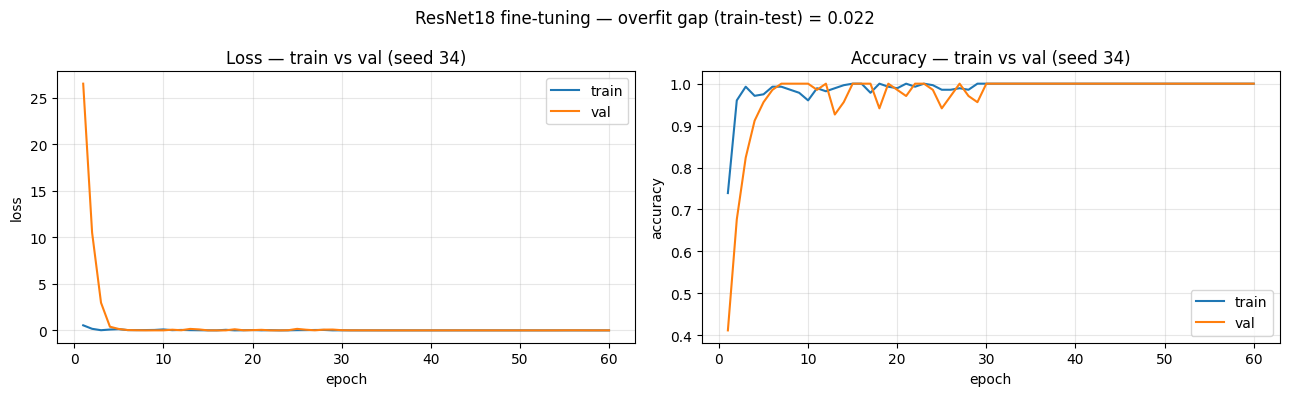

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(tv["epoch"], tv["loss"], label="train"); ax[0].plot(tv["epoch"], tv["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("Loss — train vs val (seed 34)"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(tv["epoch"], tv["acc"], label="train"); ax[1].plot(tv["epoch"], tv["val_acc"], label="val")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].set_title("Accuracy — train vs val (seed 34)"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.suptitle(f"ResNet18 fine-tuning — overfit gap (train-test) = {direct['overfit_gap_train_minus_test']:.3f}")
plt.tight_layout(); plt.savefig(OUT / "overfit_trainval_curves_seed34.png", dpi=150, bbox_inches="tight"); plt.show()

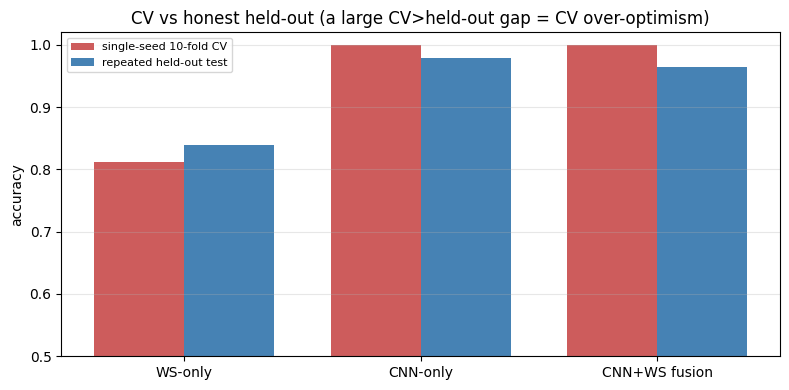

,method,cv,held_out,gap,biased
0,WS-only,0.812,0.839,-0.026,False
1,CNN-only,1.000,0.979,0.021,True
2,CNN+WS fusion,1.000,0.964,0.036,True


In [15]:
# 3. CV-vs-held-out gap (CV optimism), per replication method
g = []
for m in ["WS-only (averaged)", "CNN-only (ResNet18->kNN)", "CNN+WS fusion (concat)"]:
    a = agg(m); cvv = cvmap[m]
    g.append(dict(method=m.split(" (")[0], cv=cvv[0], held_out=a["test_acc"], gap=cvv[0]-a["test_acc"], biased=cvv[2]))
gdf = pd.DataFrame(g)
fig, ax = plt.subplots(figsize=(8, 4)); x = np.arange(len(gdf)); w = 0.38
ax.bar(x-w/2, gdf["cv"], w, label="single-seed 10-fold CV", color="indianred")
ax.bar(x+w/2, gdf["held_out"], w, label="repeated held-out test", color="steelblue")
ax.set_xticks(x); ax.set_xticklabels(gdf["method"]); ax.set_ylim(0.5, 1.02); ax.set_ylabel("accuracy")
ax.set_title("CV vs honest held-out (a large CV>held-out gap = CV over-optimism)"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "cv_vs_heldout_gap.png", dpi=150, bbox_inches="tight"); plt.show()
display(gdf.round(3))

/tmp/ipykernel_90896/1804598692.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Majority", "WS-only", "CNN-only", "CNN+WS"], showmeans=True)


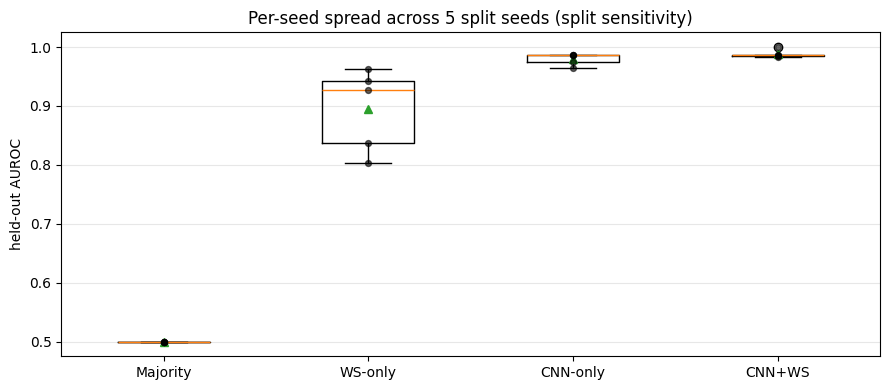

In [16]:
# 4. Per-seed spread (split sensitivity) — held-out AUROC across the 5 seeds
order = ["Majority baseline", "WS-only (averaged)", "CNN-only (ResNet18->kNN)", "CNN+WS fusion (concat)"]
data = [perseed[perseed["method"] == m]["auroc"].values for m in order]
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(data, labels=["Majority", "WS-only", "CNN-only", "CNN+WS"], showmeans=True)
for i, d in enumerate(data): ax.scatter(np.full(len(d), i+1), d, alpha=0.6, color="black", s=18, zorder=3)
ax.set_ylabel("held-out AUROC"); ax.set_title("Per-seed spread across 5 split seeds (split sensitivity)"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "per_seed_spread_auroc.png", dpi=150, bbox_inches="tight"); plt.show()

**Reading the diagnostics.** On tissue the overfit gap is *small* — training accuracy saturates near 100%
but validation/test stay high because fatty-vs-fibroglandular is highly separable, so the memorisation does
not hurt generalisation (contrast with the mass task, where the same setup overfits badly). The CV-vs-held-out
panel shows the CNN/fusion single-seed CV (≈1.0) sitting well above their honest held-out accuracy — the CV
over-optimism that inflates the paper's CV-led headline. The per-seed spread is tight for CNN/fusion and wider
for WS-only, quantifying split sensitivity on this small dataset.

### Note — the paper's overfitting argument (CNN on a small dataset)

The paper's own tissue numbers show a large gap between cross-validation and held-out test for the CNN (Razali Table 6: **99.0% CV vs 77.4% test**). That gap is the overfitting they invoke to motivate fusing the training-free WS features with the CNN: fine-tuning a deep ResNet18 on only ~400 patches lets it memorise the training set (CV / train accuracy near 100%) while generalising less well to unseen images. Prior work they cite (Yu & Wang, 2019) similarly reports that *shallower* networks can outperform very deep ones for breast-mass classification on small datasets.

In our replication the same mechanism is visible — training accuracy saturates near 100% within a few epochs — but on the **tissue** task the held-out accuracy stays high (overfit gap ≈ 0.02), because fatty-vs-fibroglandular is highly separable, so the memorisation does not hurt generalisation here. The dramatic version of this overfitting — and the case where fusion genuinely helps — is the **mass** task, shown in *FINAL Step 2.2*.